# 🏨 Hotel Booking Predictive Analytics

En este cuaderno se realiza la primera fase de exploración y auditoría diagnóstica sobre el dataset original de reservas hoteleras. El objetivo fundamental es comprender la estructura geométrica de la información, detectar inconsistencias operativas y validar la viabilidad estadística de los datos antes de alimentar el pipeline de Machine Learning.

## ⚙️ 1. Environment Setup & Data Ingestion

### Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn configuration
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


I0000 00:00:1781366161.234934    5505 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781366162.682319    5505 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781366169.732366    5505 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Load the dataset

In [2]:
path_data = "../data/raw/hotel_bookings.csv"
df_hotel = pd.read_csv(path_data)


### Global Display Configuration

In [3]:
# Pandas display configuration: prevent truncation of wide dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 📈 2. Exploratory Data Analysis (EDA)

### 2.1 Structural Profiling & Dimensionality

In [4]:
# Display the first 5 rows and dataset dimensions
print(f"The dataset has {df_hotel.shape[0]} rows and {df_hotel.shape[1]} columns.")
df_hotel.head()

The dataset has 119390 rows and 32 columns.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
# Display dataframe summary: columns, data types, and non-null counts
df_hotel.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### 2.2 Feature Type Distribution

In [6]:
# ----------- Data Type -----------
# Count of features grouped by data type
df_hotel.dtypes.value_counts()

int64      16
str        12
float64     4
Name: count, dtype: int64

In [7]:
# -------------- Categorical Features -----------
# List of categorical/text columns
categorical_cols = df_hotel.select_dtypes(include=["object", "str"]).columns.tolist()

categorical_cols

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status',
 'reservation_status_date']

In [8]:
# -------------- Numerical Features --------------
# List of numerical columns
numerical_cols = df_hotel.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_cols

['is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

### 2.3 Cardinality Audit

In [9]:
# -------------- Cardinality of Categorical Features --------------
# Number of unique values per categorical feature
df_hotel[categorical_cols].nunique().sort_values(ascending=False)

reservation_status_date    926
country                    177
assigned_room_type          12
arrival_date_month          12
reserved_room_type          10
market_segment               8
distribution_channel         5
meal                         5
customer_type                4
deposit_type                 3
reservation_status           3
hotel                        2
dtype: int64

### 2.4 Statistical Summaries & Anomaly Detection

In [10]:
# 1. Statistical summary for numerical features
print("--- Numerical Features Statistical Summary ---")
print(df_hotel.describe().T)

--- Numerical Features Statistical Summary ---
                                   count         mean         std      min      25%       50%     75%     max
is_canceled                     119390.0     0.370416    0.482918     0.00     0.00     0.000     1.0     1.0
lead_time                       119390.0   104.011416  106.863097     0.00    18.00    69.000   160.0   737.0
arrival_date_year               119390.0  2016.156554    0.707476  2015.00  2016.00  2016.000  2017.0  2017.0
arrival_date_week_number        119390.0    27.165173   13.605138     1.00    16.00    28.000    38.0    53.0
arrival_date_day_of_month       119390.0    15.798241    8.780829     1.00     8.00    16.000    23.0    31.0
stays_in_weekend_nights         119390.0     0.927599    0.998613     0.00     0.00     1.000     2.0    19.0
stays_in_week_nights            119390.0     2.500302    1.908286     0.00     1.00     2.000     3.0    50.0
adults                          119390.0     1.856403    0.579261     0.0

In [11]:
# 2. Statistical summary for categorical features
print("\n--- Categorical Features Statistical Summary ---")
print(df_hotel.describe(include=['object','str']).T)


--- Categorical Features Statistical Summary ---
                          count unique         top    freq
hotel                    119390      2  City Hotel   79330
arrival_date_month       119390     12      August   13877
meal                     119390      5          BB   92310
country                  118902    177         PRT   48590
market_segment           119390      8   Online TA   56477
distribution_channel     119390      5       TA/TO   97870
reserved_room_type       119390     10           A   85994
assigned_room_type       119390     12           A   74053
deposit_type             119390      3  No Deposit  104641
customer_type            119390      4   Transient   89613
reservation_status       119390      3   Check-Out   75166
reservation_status_date  119390    926  2015-10-21    1461


### 2.5 Data Integrity & Missing Values

In [12]:
# Filter and display only columns with missing values
nulls_summary = pd.DataFrame({
    "missing_values": df_hotel.isnull().sum(),
    "null_percentage": df_hotel.isnull().mean() * 100,
    "data_type": df_hotel.dtypes
})

# Filter and show only columns with missing values
nulls_summary[nulls_summary["missing_values"] > 0].sort_values("null_percentage", ascending=False)

,missing_values,null_percentage,data_type
company,112593,94.306893,float64
agent,16340,13.686238,float64
country,488,0.408744,str
children,4,0.003350,float64


### 2.6 Potential Data Leakage Audit

Las variables `reservation_status` y `reservation_status_date` se excluirán explícitamente del proceso de entrenamiento de los modelos debido a las siguientes restricciones críticas:

* **`reservation_status`:** Contiene el estado operativo final de la reserva (por ejemplo, `Check-Out`, `Canceled` o `No-Show`). Esta característica está directa y perfectamente correlacionada con nuestra variable objetivo `is_canceled`, lo que representa un caso clásico de redundancia de *target*.
* **`reservation_status_date`:** Registra la fecha exacta en la que se actualizó el estado final, por lo que también puede incluir información posterior al momento real de predicción.


In [13]:
# Audit the distribution of reservation_status to verify target redundancy (Data Leakage check)
df_hotel['reservation_status'].value_counts(dropna=False)

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [14]:
# Drop columns that cause Data Leakage
columns_to_drop = ['reservation_status', 'reservation_status_date']
df_hotel = df_hotel.drop(columns=columns_to_drop)

print(f"Columns dropped successfully. Current column count: {df_hotel.shape[1]}")

Columns dropped successfully. Current column count: 30


## 📊 3. Bivariate Analysis & Target Feature Correlations

### 3.1 Target Class Balance

Cancellation Distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Cancellation Percentages:
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


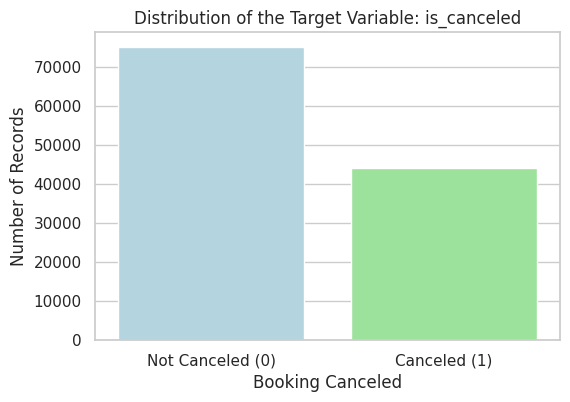

In [15]:
# Count the occurrences of each class (0 = Not Canceled, 1 = Canceled)
cancellation_counts = df_hotel['is_canceled'].value_counts()

# Print the results
print("Cancellation Distribution:")
print(cancellation_counts)

# Get the percentage 
cancellation_percentages = df_hotel['is_canceled'].value_counts(normalize=True) * 100
print("\nCancellation Percentages:")
print(cancellation_percentages)

# Visualization
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df_hotel, x='is_canceled', 
    hue='is_canceled', 
    palette=["lightblue", "lightgreen"], 
    legend=False
    )

plt.xticks(ticks=[0, 1], labels=["Not Canceled (0)", "Canceled (1)"])

plt.title("Distribution of the Target Variable: is_canceled")
plt.xlabel("Booking Canceled")
plt.ylabel("Number of Records")

plt.show()

### 3.2 Cancellation Drivers by Feature

--- Cancellation Rate by Hotel Type ---
hotel
City Hotel      41.726963
Resort Hotel    27.763355
Name: is_canceled, dtype: float64


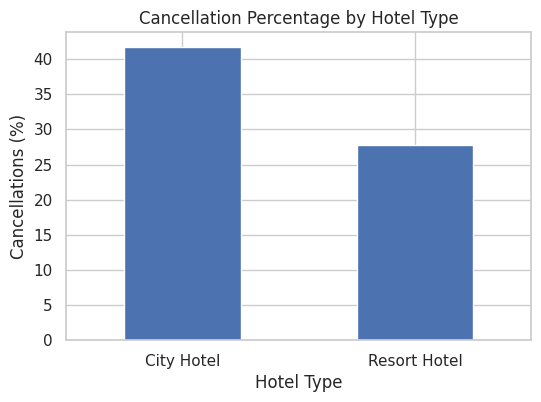

In [16]:
# ----- Hotel Type vs. Cancellation Rate -----
# Calculate cancellation percentage by hotel type
cancel_by_hotel = df_hotel.groupby("hotel")["is_canceled"].mean().sort_values(ascending=False) * 100
print("--- Cancellation Rate by Hotel Type ---")
print(cancel_by_hotel)

# Plot: Cancellation rate by hotel type
plt.figure(figsize=(6, 4))
cancel_by_hotel.plot(kind="bar")
plt.title("Cancellation Percentage by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellations (%)")
plt.xticks(rotation=0)
plt.show()


--- Cancellation Rate by Deposit Type ---
deposit_type
Non Refund    99.362446
No Deposit    28.377022
Refundable    22.222222
Name: is_canceled, dtype: float64


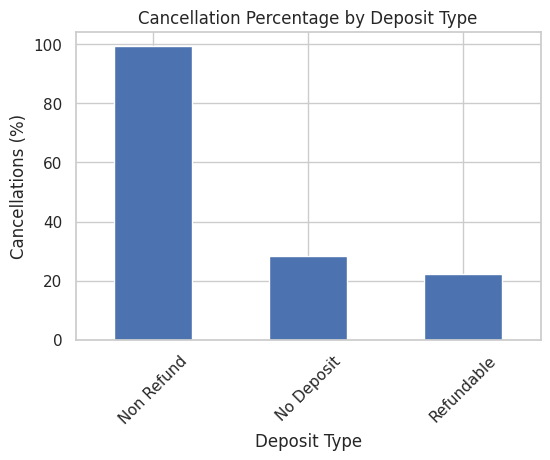

In [17]:
# ----- Deposit Type vs. Cancellation Rate -----
# Calculate cancellation percentage by deposit type
cancel_by_deposit = df_hotel.groupby("deposit_type")["is_canceled"].mean().sort_values(ascending=False) * 100
print("\n--- Cancellation Rate by Deposit Type ---")
print(cancel_by_deposit)

# Plot: Cancellation rate by deposit type
plt.figure(figsize=(6, 4))
cancel_by_deposit.plot(kind="bar")
plt.title("Cancellation Percentage by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellations (%)")
plt.xticks(rotation=45)
plt.show()


--- Cancellation Rate by Market Segment ---
market_segment
Undefined        100.000000
Groups            61.062036
Online TA         36.721143
Offline TA/TO     34.316033
Aviation          21.940928
Corporate         18.734655
Direct            15.341901
Complementary     13.055182
Name: is_canceled, dtype: float64


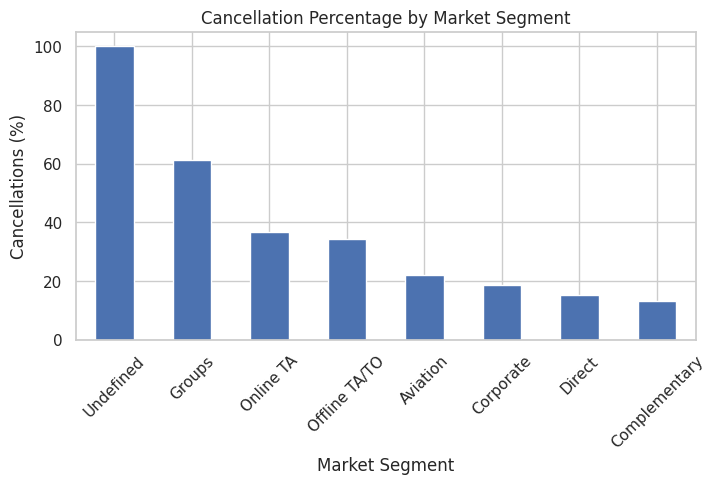

In [18]:
# ----- Market Segment vs. Cancellation Rate -----
# Calculate cancellation percentage by market segment
cancel_by_market = df_hotel.groupby("market_segment")["is_canceled"].mean().sort_values(ascending=False) * 100
print("\n--- Cancellation Rate by Market Segment ---")
print(cancel_by_market)

# Plot: Cancellation rate by market segment
plt.figure(figsize=(8, 4))
cancel_by_market.plot(kind="bar")
plt.title("Cancellation Percentage by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellations (%)")
plt.xticks(rotation=45)
plt.show()


--- Numerical Correlations with is_canceled ---
is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
children                          0.005048
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.006130
company                          -0.020642
babies                           -0.032491
previous_bookings_not_canceled   -0.057358
agent                            -0.083114
is_repeated_guest                -0.084793
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
Name: is_canceled, dtype: float64


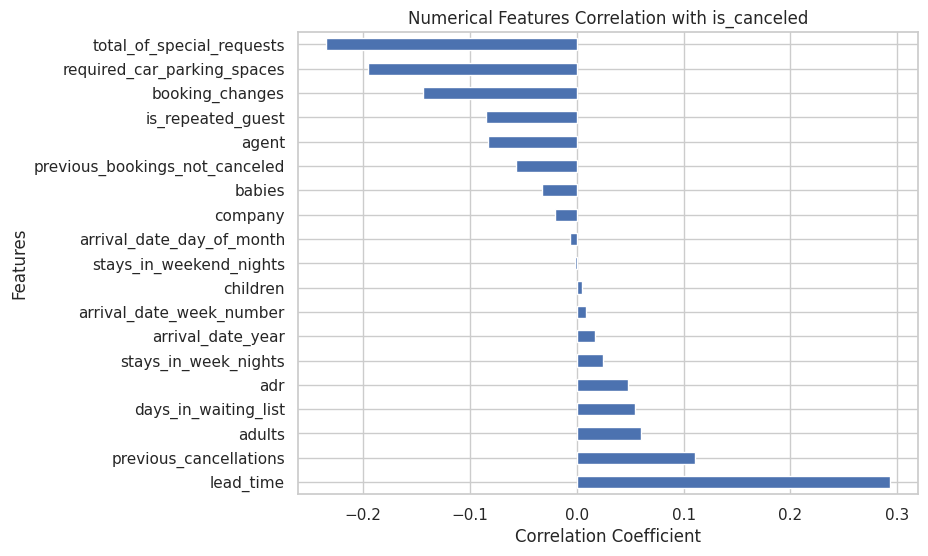

In [19]:
# ----- Numerical Feature Correlations with Target -----
# Compute linear correlation of numerical features with the target variable
numeric_corr = df_hotel[numerical_cols].corr(numeric_only=True)["is_canceled"].sort_values(ascending=False)
print("\n--- Numerical Correlations with is_canceled ---")
print(numeric_corr)

# Plot: Feature correlation coefficients with the target variable
plt.figure(figsize=(8, 6))
numeric_corr.drop("is_canceled").plot(kind="barh")
plt.title("Numerical Features Correlation with is_canceled")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()

## 🛠️ 4. Guidelines for Data Cleaning and Preprocessing

Basado en el diagnóstico y la auditoría de calidad de datos realizada previamente, se establecen las siguientes decisiones estratégicas para el diseño de nuestro pipeline:

### 💾 1. Integridad del Entorno y Arquitectura de Datos Crudos
* **Inmutabilidad del Origen:** El dataset original permanecerá completamente intacto y en modo de solo lectura dentro del directorio `data/raw/` para garantizar la reproducibilidad estructural en todas las iteraciones posteriores del experimento.

### 🛡️ 2. Mitigación de Sesgos y Defensa contra la Fuga de Datos (Data Leakage)
* **Remoción de Data Leakage:** Las características que actúan como sustitutos de la variable objetivo o que revelan información del futuro (`reservation_status`, `reservation_status_date`) se eliminan estrictamente antes de cualquier partición de datos. Esto asegura que el modelo solo evalúe variables conocidas en el momento real de la reserva.
* **Control de Redundancia (Preservación de Duplicados por Lógica de Negocio):** El dataset contiene 32,252 filas idénticas. Estos registros se conservan intencionalmente basándose en la lógica del dominio: en las operaciones hoteleras donde no existe un ID único de reserva, las filas idénticas representan reservas legítimas en bloque o al por mayor de operadores turísticos y eventos grupales. Eliminarlas subestimaría artificialmente el volumen y el alto impacto de cancelación del segmento de Grupos.
* **Aislamiento Estricto de Datos:** Para prevenir la contaminación de información, la partición de datos (Train-Test Split) se ejecuta *antes* de cualquier transformación de escala. Los parámetros de la distribución de entrenamiento se aíslan por completo del conjunto de prueba.

### ⚙️ 3. Reglas de la Arquitectura del Pipeline e Ingeniería de Características
Cada transformación de datos con estado se encapsula estrictamente de forma programática dentro del flujo de ejecución del pipeline:
* **Tratamiento de Valores Nulos (Estrategia de Imputación y Descarte):** * Los valores faltantes en características geográficas (ej. `country`) se resuelven inyectando una categoría controlada (`'Unknown'`) para preservar el registro.
  * El atributo operativo `agent` se imputa utilizando un identificador de respaldo (`0`), lo que significa reservas directas realizadas sin intermediarios.
  * La característica `company` se descarta por completo del pipeline debido a que presenta más del 94% de valores nulos, evitando la introducción de ruido estadístico o sesgos por imputación masiva.
* **Codificación Categórica (Expansión por One-Hot Encoding):** Los factores cualitativos categóricos se convierten mediante un One-Hot Encoding estricto. El motor de producción aplica una regla de alineación de esquema posterior (`.reindex`) para mantener una matriz determinista de 247 variables ordenadas alfabéticamente.
* **Escalamiento Estadístico (Geometría del StandardScaler):** Las variables numéricas se transforman mediante un `StandardScaler` centralizado. Esto alinea los valores a una estructura de media cero y varianza unitaria, optimizando la convergencia del descenso de gradiente para estimadores altamente sensibles a la magnitud, como la Regresión Logística y la Red Neuronal de TensorFlow.

### 4.1 Dataset Cleaning Execution

In [20]:
# Anomaly detected
df_hotel = df_hotel[df_hotel['adr'] >= 0]
print(f"\n--> Data Cleaning: Anomalous negative ADR value removed. New dataset shape: {df_hotel.shape}")


--> Data Cleaning: Anomalous negative ADR value removed. New dataset shape: (119389, 30)


In [21]:

# Drop the 'company' column
df_hotel = df_hotel.drop(columns=['company'])

# Impute missing values in 'agent' with 0 
df_hotel['agent'] = df_hotel['agent'].fillna(0)

# Impute missing values in 'country' with 'Unknown'
df_hotel['country'] = df_hotel['country'].fillna('Unknown')

# Impute missing values in 'children' with 0
df_hotel['children'] = df_hotel['children'].fillna(0)

# Verify that the dataset is completely clean
print("Maximum number of remaining nulls in any column:")
print(df_hotel.isnull().sum().max())

Maximum number of remaining nulls in any column:
0


## Data Preprocessing

### 4.2 Feature-target split (X and y)

In [22]:
# Define 'X' (Independent Variables)
# We take the entire dataset but drop the target column
X = df_hotel.drop(columns=['is_canceled'])

# Define 'y' (Dependent Variable)
y = df_hotel['is_canceled']

# Verify the dimensions
print(f"Shape of X (Matrix): {X.shape}")
print(f"Shape of y (Vector): {y.shape}")

Shape of X (Matrix): (119389, 28)
Shape of y (Vector): (119389,)


### 4.3 Train/Test Split

In [23]:
# Split the dataset into Training (80%) and Testing (20%) sets using raw features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Verify the dimensions of the generated splits
print("--- Training Set ---")
print(f"X_train shape (Features for learning): {X_train.shape}")
print(f"y_train shape (Labels for learning): {y_train.shape}\n")

print("--- Testing Set ---")
print(f"X_test shape (Features for the exam): {X_test.shape}")
print(f"y_test shape (Labels for grading): {y_test.shape}")

--- Training Set ---
X_train shape (Features for learning): (95511, 28)
y_train shape (Labels for learning): (95511,)

--- Testing Set ---
X_test shape (Features for the exam): (23878, 28)
y_test shape (Labels for grading): (23878,)


### 4.4 Categorical Encoding

In [24]:
# (One-Hot Encoding)

# Automatically detect all columns containing text from the training split
text_columns = X_train.select_dtypes(include=['object', 'str']).columns
print("Categorical columns to be transformed:\n", list(text_columns))

Categorical columns to be transformed:
 ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [25]:
# Apply One-Hot Encoding independently to Training and Testing sets
X_train_encoded = pd.get_dummies(X_train, columns=text_columns, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=text_columns, drop_first=True)

# Align columns to ensure both sets have the exact same features
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Clean up column names by replacing spaces with underscores
X_train_encoded.columns = X_train_encoded.columns.str.replace(' ', '_')
X_test_encoded.columns = X_test_encoded.columns.str.replace(' ', '_')

In [26]:
# Compare the shape of the datasets before and after the transformation
print(f"Dimensions of X_train before encoding: {X_train.shape}")
print(f"Dimensions of X_train after encoding:  {X_train_encoded.shape}")
print("-" * 50)
print(f"Dimensions of X_test before encoding:  {X_test.shape}")
print(f"Dimensions of X_test after encoding:   {X_test_encoded.shape}")

Dimensions of X_train before encoding: (95511, 28)
Dimensions of X_train after encoding:  (95511, 243)
--------------------------------------------------
Dimensions of X_test before encoding:  (23878, 28)
Dimensions of X_test after encoding:   (23878, 243)


In [27]:
# Print all column names
column_names = X_train_encoded.columns.tolist()
print("Total columns:", len(column_names))
print("List of columns:\n", column_names)

Total columns: 243
List of columns:
 ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'hotel_Resort_Hotel', 'arrival_date_month_August', 'arrival_date_month_December', 'arrival_date_month_February', 'arrival_date_month_January', 'arrival_date_month_July', 'arrival_date_month_June', 'arrival_date_month_March', 'arrival_date_month_May', 'arrival_date_month_November', 'arrival_date_month_October', 'arrival_date_month_September', 'meal_FB', 'meal_HB', 'meal_SC', 'meal_Undefined', 'country_AGO', 'country_AIA', 'country_ALB', 'country_AND', 'country_ARE', 'country_ARG', 'country_ARM', 'country_ASM', 'country_ATA', 'country_ATF', 'country_AUS', 'country_AUT', 'country_AZE'

### 4.5 Feature Scaling

In [28]:
# Automatically detect the original numerical columns from the source matrix X
num_columns = X.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns to be scaled:\n", list(num_columns))

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the Encoded Training matrix
X_train_encoded[num_columns] = scaler.fit_transform(X_train_encoded[num_columns])

# Transform the Encoded Testing matrix (using Train parameters to avoid leakage)
X_test_encoded[num_columns] = scaler.transform(X_test_encoded[num_columns])

Numerical columns to be scaled:
 ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [29]:
# Inspect the final output of the entire Data Preprocessing Phase
X_train_encoded.head()

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,hotel_Resort_Hotel,arrival_date_month_August,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,meal_FB,meal_HB,meal_SC,meal_Undefined,country_AGO,country_AIA,country_ALB,country_AND,country_ARE,country_ARG,country_ARM,country_ASM,country_ATA,country_ATF,country_AUS,country_AUT,country_AZE,country_BDI,country_BEL,country_BEN,country_BFA,country_BGD,country_BGR,country_BHR,country_BHS,country_BIH,country_BLR,country_BOL,country_BRA,country_BRB,country_CAF,country_CHE,country_CHL,country_CHN,country_CIV,country_CMR,country_CN,country_COL,country_COM,country_CPV,country_CRI,country_CUB,country_CYM,country_CYP,country_CZE,country_DEU,country_DMA,country_DNK,country_DOM,country_DZA,country_ECU,country_EGY,country_ESP,country_EST,country_ETH,country_FIN,country_FJI,country_FRA,country_FRO,country_GAB,country_GBR,country_GEO,country_GGY,country_GHA,country_GIB,country_GLP,country_GNB,country_GRC,country_GTM,country_GUY,country_HKG,country_HND,country_HRV,country_HUN,country_IDN,country_IMN,country_IND,country_IRL,country_IRN,country_IRQ,country_ISL,country_ISR,country_ITA,country_JAM,country_JEY,country_JOR,country_JPN,country_KAZ,country_KEN,country_KHM,country_KNA,country_KOR,country_KWT,country_LAO,country_LBN,country_LBY,country_LIE,country_LKA,country_LTU,country_LUX,country_LVA,country_MAC,country_MAR,country_MCO,country_MDG,country_MDV,country_MEX,country_MKD,country_MLI,country_MLT,country_MMR,country_MNE,country_MOZ,country_MRT,country_MUS,country_MWI,country_MYS,country_MYT,country_NAM,country_NCL,country_NGA,country_NIC,country_NLD,country_NOR,country_NPL,country_NZL,country_OMN,country_PAK,country_PAN,country_PER,country_PHL,country_PLW,country_POL,country_PRI,country_PRT,country_PRY,country_PYF,country_QAT,country_ROU,country_RUS,country_RWA,country_SAU,country_SDN,country_SEN,country_SGP,country_SLE,country_SLV,country_SMR,country_SRB,country_STP,country_SUR,country_SVK,country_SVN,country_SWE,country_SYC,country_SYR,country_TGO,country_THA,country_TJK,country_TMP,country_TUN,country_TUR,country_TWN,country_TZA,country_UGA,country_UKR,country_UMI,country_URY,country_USA,country_UZB,country_Unknown,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline_TA/TO,market_segment_Online_TA,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_Non_Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
27738,1.244174,-0.221318,0.725623,-1.342097,1.076910,0.264492,1.959992,-0.25982,-0.08038,-0.180853,-0.104004,-0.090764,-0.337536,0.937177,-0.132795,0.637656,-0.254035,-0.718424,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [30]:
# Inspect the test matrix to verify successful scaling
X_test_encoded.head()

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,hotel_Resort_Hotel,arrival_date_month_August,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,meal_FB,meal_HB,meal_SC,meal_Undefined,country_AGO,country_AIA,country_ALB,country_AND,country_ARE,country_ARG,country_ARM,country_ASM,country_ATA,country_ATF,country_AUS,country_AUT,country_AZE,country_BDI,country_BEL,country_BEN,country_BFA,country_BGD,country_BGR,country_BHR,country_BHS,country_BIH,country_BLR,country_BOL,country_BRA,country_BRB,country_CAF,country_CHE,country_CHL,country_CHN,country_CIV,country_CMR,country_CN,country_COL,country_COM,country_CPV,country_CRI,country_CUB,country_CYM,country_CYP,country_CZE,country_DEU,country_DMA,country_DNK,country_DOM,country_DZA,country_ECU,country_EGY,country_ESP,country_EST,country_ETH,country_FIN,country_FJI,country_FRA,country_FRO,country_GAB,country_GBR,country_GEO,country_GGY,country_GHA,country_GIB,country_GLP,country_GNB,country_GRC,country_GTM,country_GUY,country_HKG,country_HND,country_HRV,country_HUN,country_IDN,country_IMN,country_IND,country_IRL,country_IRN,country_IRQ,country_ISL,country_ISR,country_ITA,country_JAM,country_JEY,country_JOR,country_JPN,country_KAZ,country_KEN,country_KHM,country_KNA,country_KOR,country_KWT,country_LAO,country_LBN,country_LBY,country_LIE,country_LKA,country_LTU,country_LUX,country_LVA,country_MAC,country_MAR,country_MCO,country_MDG,country_MDV,country_MEX,country_MKD,country_MLI,country_MLT,country_MMR,country_MNE,country_MOZ,country_MRT,country_MUS,country_MWI,country_MYS,country_MYT,country_NAM,country_NCL,country_NGA,country_NIC,country_NLD,country_NOR,country_NPL,country_NZL,country_OMN,country_PAK,country_PAN,country_PER,country_PHL,country_PLW,country_POL,country_PRI,country_PRT,country_PRY,country_PYF,country_QAT,country_ROU,country_RUS,country_RWA,country_SAU,country_SDN,country_SEN,country_SGP,country_SLE,country_SLV,country_SMR,country_SRB,country_STP,country_SUR,country_SVK,country_SVN,country_SWE,country_SYC,country_SYR,country_TGO,country_THA,country_TJK,country_TMP,country_TUN,country_TUR,country_TWN,country_TZA,country_UGA,country_UKR,country_UMI,country_URY,country_USA,country_UZB,country_Unknown,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline_TA/TO,market_segment_Online_TA,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_Non_Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
93582,-0.195646,-0.221318,0.211297,0.819735,-0.927040,-0.784720,0.248536,-0.259820,-0.08038,-0.180853,-0.104004,-0.090764,-0.337536,-0.623459,-0.132795,0.069420,-0.254035,0.544713,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,0,0,False,False,False,False,False,0,False,0,False,False,False,0,False,0,0,False,False,0,0,False,False,False,False,0,False,False,False,False,False,Fa

## 🧠 5. Model Training and Evaluation

### 5.1 Training the Baseline Models

#### Logistic Regression

In [31]:
# =========================================================
# 1. LOGISTIC REGRESSION (Baseline Model 1)
# =========================================================
print("--- Training Logistic Regression Model ---")

# Initialize the model with a max_iter limit to ensure convergence
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using the training data
log_reg.fit(X_train_encoded, y_train)

# Generate predictions on the unseen test set
y_pred_log_reg = log_reg.predict(X_test_encoded)

# Extract only column [:, 1], which represents the probability of cancellation (Class 1)
y_proba_log_reg = log_reg.predict_proba(X_test_encoded)[:, 1]

# Evaluate the performance metrics
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Logistic Regression ROC-AUC:  {roc_auc_score(y_test, y_proba_log_reg):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))

print("\n" + "="*60 + "\n")

--- Training Logistic Regression Model ---
Logistic Regression Accuracy: 0.8166
Logistic Regression ROC-AUC:  0.8949

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86     15033
           1       0.81      0.66      0.73      8845

    accuracy                           0.82     23878
   macro avg       0.81      0.79      0.80     23878
weighted avg       0.82      0.82      0.81     23878





#### Decision Tree

In [32]:
# =========================================================
# 2. DECISION TREE (Baseline Model 2)
# =========================================================
print("--- Training Decision Tree Model ---")

# Initialize the model with max_depth to control overfitting
tree_clf = DecisionTreeClassifier(max_depth=10, random_state=42)

# Train the model using the training data
tree_clf.fit(X_train_encoded, y_train)

# Generate predictions on the unseen test set
y_pred_tree = tree_clf.predict(X_test_encoded)

# Extract only column [:, 1], which represents the probability of cancellation (Class 1)
y_proba_tree = tree_clf.predict_proba(X_test_encoded)[:, 1]

# Evaluate the performance metrics
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Decision Tree ROC-AUC:  {roc_auc_score(y_test, y_proba_tree):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

print("\n" + "="*60 + "\n")

--- Training Decision Tree Model ---
Decision Tree Accuracy: 0.8438
Decision Tree ROC-AUC:  0.9224

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88     15033
           1       0.83      0.73      0.78      8845

    accuracy                           0.84     23878
   macro avg       0.84      0.82      0.83     23878
weighted avg       0.84      0.84      0.84     23878





#### Random Forest

In [33]:
# ==============================================================================
# 3. RANDOM FOREST (Advanced Ensemble Model 1)
# ==============================================================================
print("--- Training Random Forest Model ---")

# Initialize the ensemble model with tuned hyperparameters for performance
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

# Train the model using the training data
rf_clf.fit(X_train_encoded, y_train)

# Generate predictions on the unseen test set
y_pred_rf = rf_clf.predict(X_test_encoded)

y_proba_rf = rf_clf.predict_proba(X_test_encoded)[:, 1]

# Evaluate the performance metrics
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest ROC-AUC:  {roc_auc_score(y_test, y_proba_rf):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

print("\n" + "="*60 + "\n")

--- Training Random Forest Model ---
Random Forest Accuracy: 0.8328
Random Forest ROC-AUC:  0.9273

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.97      0.88     15033
           1       0.91      0.61      0.73      8845

    accuracy                           0.83     23878
   macro avg       0.86      0.79      0.80     23878
weighted avg       0.85      0.83      0.82     23878





#### Training XGBoost

In [34]:
# ==============================================================================
# 4. GRADIENT BOOSTING - XGBOOST (Advanced Ensemble Model 2)
# ==============================================================================
print("--- Training XGBoost Model ---")

# Initialize the extreme gradient boosting classifier
xgb_clf = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)

# Train the model using the training data
xgb_clf.fit(X_train_encoded, y_train)

# Generate predictions on the unseen test set
y_pred_xgb = xgb_clf.predict(X_test_encoded)

y_proba_xgb = xgb_clf.predict_proba(X_test_encoded)[:, 1]

# Evaluate the performance metrics
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"XGBoost ROC-AUC:  {roc_auc_score(y_test, y_proba_xgb):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

print("\n" + "="*60 + "\n")

--- Training XGBoost Model ---
XGBoost Accuracy: 0.8672
XGBoost ROC-AUC:  0.9433

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90     15033
           1       0.86      0.77      0.81      8845

    accuracy                           0.87     23878
   macro avg       0.87      0.85      0.85     23878
weighted avg       0.87      0.87      0.87     23878





#### Deep Learning Model (Keras/TensorFlow)

In [35]:
# ==============================================================================
# 5. MULTI-LAYER PERCEPTRON / NEURAL NETWORK (Deep Learning Model)
# ==============================================================================
print("--- Training Deep Learning Model (Keras/TensorFlow) ---")

# Define the network architecture
model = Sequential([
    # Input layer implicitly matching X_train shape, connected to the first hidden layer
    Dense(64, activation='relu', input_shape=(X_train_encoded.shape[1],)),
    Dropout(0.3), 
    
    # Second hidden layer
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')
])

# Compile the model 
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the neural network model
history = model.fit(
    X_train_encoded, y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)

# Generate probability predictions and convert them to binary classes (0 or 1)
y_pred_probs = model.predict(X_test_encoded)
y_pred_nn = (y_pred_probs > 0.5).astype(int).flatten()

# Evaluate the final performance metrics
print("\n" + "="*60 + "\n")
print(f"Neural Network Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"Neural Network ROC-AUC:  {roc_auc_score(y_test, y_pred_probs):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))

--- Training Deep Learning Model (Keras/TensorFlow) ---


/home/marvin/workspace/proyecto-final-ml/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1781366318.635726    5505 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781366318.636928    6145 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1781366318.696937    5505 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if 

Epoch 1/10
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8156 - loss: 0.3874 - val_accuracy: 0.8470 - val_loss: 0.3326
Epoch 2/10
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8436 - loss: 0.3339 - val_accuracy: 0.8533 - val_loss: 0.3211
Epoch 3/10
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8516 - loss: 0.3195 - val_accuracy: 0.8581 - val_loss: 0.3108
Epoch 4/10
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8562 - loss: 0.3108 - val_accuracy: 0.8600 - val_loss: 0.3070
Epoch 5/10
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8582 - loss: 0.3047 - val_accuracy: 0.8585 - val_loss: 0.3064
Epoch 6/10
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8611 - loss: 0.3005 - val_accuracy: 0.8601 - val_loss: 0.3012
Epoch 7/10
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8642 - loss: 0.2953 - val_accuracy: 0.8662 - val_loss: 0.2966
Epoch 8/10
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8649 - loss: 0.2948 - 

### 5.2 Model Comparison Summary

In [36]:
import pandas as pd
from sklearn.metrics import f1_score

# ==============================================================================
# FASE 4: MODEL COMPARISON AND FINAL SUMMARY
# ==============================================================================
print("--- Generating Model Comparison Summary ---")

# 1. Gather accuracy and F1-score metrics for all trained models
# Note: pos_label=1 extracts the specific performance for the cancellation class
results_data = {
    "Model": [
        "Logistic Regression", 
        "Decision Tree", 
        "Random Forest", 
        "XGBoost", 
        "Neural Network (Keras)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_nn)
    ],
    "F1-Score (Canceled)": [
        f1_score(y_test, y_pred_log_reg, pos_label=1),
        f1_score(y_test, y_pred_tree, pos_label=1),
        f1_score(y_test, y_pred_rf, pos_label=1),
        f1_score(y_test, y_pred_xgb, pos_label=1),
        f1_score(y_test, y_pred_nn, pos_label=1)
    ]
}

# 2. Convert the dictionary into a formatted Pandas DataFrame
df_comparison = pd.DataFrame(results_data)

# 3. Sort the models by performance (highest Accuracy first)
df_comparison = df_comparison.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

# 4. Display the final comparison matrix
df_comparison

--- Generating Model Comparison Summary ---


,Model,Accuracy,F1-Score (Canceled)
0,XGBoost,0.867200,0.810766
1,Neural Network (Keras),0.863682,0.801875
2,Decision Tree,0.843831,0.775699
3,Random Forest,0.832817,0.728620
4,Logistic Regression,0.816609,0.728468


## 6. Technical Evaluation & Production Visualization

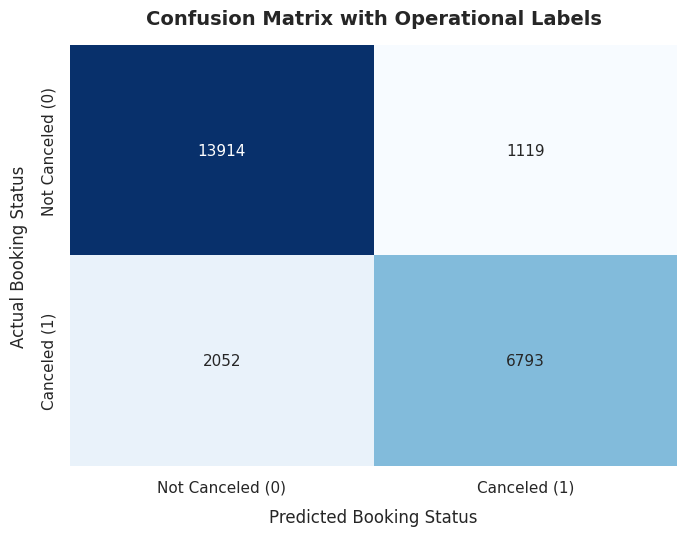

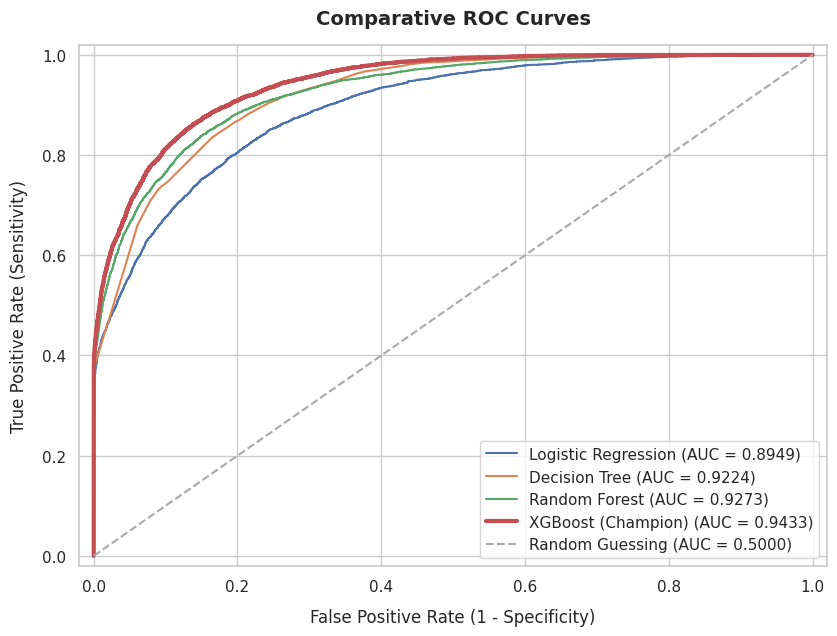

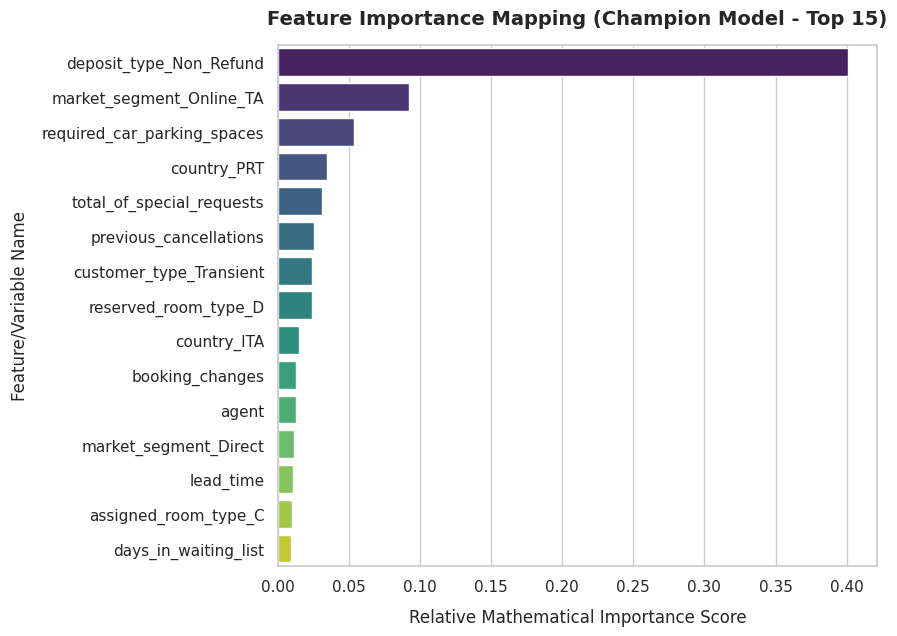

In [37]:
# ==============================================================================
# SECTION: Technical Evaluation & Production Visualization
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Set beautiful plotting styles for production-grade reports
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# THE CONTROL SWITCH: Define who is the champion in the notebook
champion_model = xgb_clf  

# ------------------------------------------------------------------------------
# 1. Confusion Matrix with Operational Labels
# ------------------------------------------------------------------------------
y_pred_champion = champion_model.predict(X_test_encoded)
cm = confusion_matrix(y_test, y_pred_champion)

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    cbar=False,
    xticklabels=["Not Canceled (0)", "Canceled (1)"],
    yticklabels=["Not Canceled (0)", "Canceled (1)"]
)
plt.title("Confusion Matrix with Operational Labels", pad=15, fontweight='bold')
plt.xlabel("Predicted Booking Status", labelpad=10)
plt.ylabel("Actual Booking Status", labelpad=10)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 2. Comparative ROC Curves
# ------------------------------------------------------------------------------
plt.figure(figsize=(8.5, 6.5))

# The dictionary remains intact because it draws ALL competitors to compare them
models_to_plot = {
    "Logistic Regression": log_reg,
    "Decision Tree": tree_clf,
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf
}

for label, model_obj in models_to_plot.items():
    if hasattr(model_obj, "predict_proba"):
        y_proba = model_obj.predict_proba(X_test_encoded)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        
        # Thicker line if this model matches the current champion_model object
        lw = 3.0 if model_obj == champion_model else 1.5
        label_text = f"{label} (Champion) (AUC = {roc_auc:.4f})" if model_obj == champion_model else f"{label} (AUC = {roc_auc:.4f})"
        
        plt.plot(fpr, tpr, label=label_text, linewidth=lw)

# Reference line representing absolute random guessing (baseline)
plt.plot([0, 1], [0, 1], color="darkgray", linestyle="--", label="Random Guessing (AUC = 0.5000)")

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.title("Comparative ROC Curves", pad=15, fontweight='bold')
plt.xlabel("False Positive Rate (1 - Specificity)", labelpad=10)
plt.ylabel("True Positive Rate (Sensitivity)", labelpad=10)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 3. Feature Importance Mapping (Champion Model)
# ------------------------------------------------------------------------------
# It automatically extracts the importances from whichever model is the champion
if hasattr(champion_model, "feature_importances_"):
    importances = champion_model.feature_importances_
    feature_names = X_train_encoded.columns
    indices = np.argsort(importances)[::-1][:15]

    plt.figure(figsize=(9, 6.5))
    sns.barplot(
        x=importances[indices], 
        y=feature_names[indices], 
        palette="viridis",
        hue=feature_names[indices],
        legend=False
    )
    plt.title("Feature Importance Mapping (Champion Model - Top 15)", pad=15, fontweight='bold')
    plt.xlabel("Relative Mathematical Importance Score", labelpad=10)
    plt.ylabel("Feature/Variable Name", labelpad=10)
    plt.tight_layout()
    plt.show()
else:
    print("The selected champion model architecture does not support feature_importances_ natively.")